# Mixture of Experts - Gating Network

Implement and train the gating network that combines predictions from all expert models.

**Gating Strategies**:
1. **Uniform**: Equal weight to all experts
2. **Confidence-based**: Weight by expert confidence (likelihood scores)
3. **Learned**: Neural network learns optimal expert weighting

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import pickle
import json

# Configuration
SEED = 42
np.random.seed(SEED)

# Paths (relative to notebook location)
ROOT = Path.cwd().parents[1]
DATA_DIR = ROOT / 'data' / 'processed' / 'MoE-anomaly'
SPLITS_DIR = DATA_DIR / 'splits'
SCALERS_DIR = DATA_DIR / 'scalers'
FIGS_DIR = DATA_DIR / 'figs'
MODELS_DIR = ROOT / 'models' / 'anomaly-detection'

# Expert names
EXPERT_NAMES = ['expert1_tire', 'expert2_dynamics', 'expert3_control', 'expert4_power']

print(f"Models directory: {MODELS_DIR}")
print(f"Data directory: {SPLITS_DIR}")
print("Environment setup complete")

Models directory: c:\Users\victo\Desktop\Documents\Cuarto Año\Primer Cuatrimestre\F1_AC_Digital_Twin\models\anomaly-detection
Data directory: c:\Users\victo\Desktop\Documents\Cuarto Año\Primer Cuatrimestre\F1_AC_Digital_Twin\data\processed\MoE-anomaly\splits
Environment setup complete


## 1. Load Expert Models

Load all trained GMM expert models.

In [13]:
# Load expert GMM models and metadata
experts = {}
thresholds = {}
metadata = {}

for expert_name in EXPERT_NAMES:
    # Load model
    model_path = MODELS_DIR / f'gmm_{expert_name}.pkl'
    with open(model_path, 'rb') as f:
        experts[expert_name] = pickle.load(f)
    
    # Load metadata (includes threshold)
    metadata_path = MODELS_DIR / f'gmm_{expert_name}_metadata.json'
    with open(metadata_path, 'r') as f:
        metadata[expert_name] = json.load(f)
        thresholds[expert_name] = metadata[expert_name]['threshold']

print("Loaded experts:")
for name, model in experts.items():
    print(f"  {name}: {model.n_components} components, threshold={thresholds[name]:.3f}")

Loaded experts:
  expert1_tire: 5 components, threshold=-94.075
  expert2_dynamics: 5 components, threshold=20.860
  expert3_control: 5 components, threshold=-32.553
  expert4_power: 5 components, threshold=-27.998


## 2. Load Expert Data

Load preprocessed data for each expert.

In [14]:
def load_expert_data(expert_name, splits_dir):
    """Load train/val/test data for an expert."""
    splits = {}
    for split_name in ['train', 'val', 'test']:
        filepath = splits_dir / f"{expert_name}_{split_name}.csv"
        splits[split_name] = pd.read_csv(filepath)
    return splits

def compute_expert_scores(gmm, data, feature_cols):
    """Compute anomaly scores (negative log-likelihood)."""
    X = data[feature_cols].values
    log_likelihood = gmm.score_samples(X)
    return -log_likelihood

# Load data and compute scores for each expert
expert_data = {}
META_COLS = ['Timestamp', 'CompletedLaps', 'Distance', 'CurrentSectorIndex', 'IsInPit']

for expert_name in EXPERT_NAMES:
    print(f"\nProcessing {expert_name}...")
    
    # Load data splits
    data_splits = load_expert_data(expert_name, SPLITS_DIR)
    
    # Get feature columns
    feature_cols = [col for col in data_splits['train'].columns if col not in META_COLS]
    
    # Compute scores
    expert_data[expert_name] = {
        'X_train': data_splits['train'][feature_cols].values,
        'X_val': data_splits['val'][feature_cols].values,
        'X_test': data_splits['test'][feature_cols].values,
        'train_scores': compute_expert_scores(experts[expert_name], data_splits['train'], feature_cols),
        'val_scores': compute_expert_scores(experts[expert_name], data_splits['val'], feature_cols),
        'test_scores': compute_expert_scores(experts[expert_name], data_splits['test'], feature_cols)
    }
    
    print(f"  Train: {expert_data[expert_name]['X_train'].shape}")
    print(f"  Val: {expert_data[expert_name]['X_val'].shape}")
    print(f"  Test: {expert_data[expert_name]['X_test'].shape}")


Processing expert1_tire...
  Train: (124941, 20)
  Val: (26763, 20)
  Test: (26804, 20)

Processing expert2_dynamics...
  Train: (124941, 20)
  Val: (26763, 20)
  Test: (26804, 20)

Processing expert2_dynamics...
  Train: (124941, 15)
  Val: (26763, 15)
  Test: (26804, 15)

Processing expert3_control...
  Train: (124941, 15)
  Val: (26763, 15)
  Test: (26804, 15)

Processing expert3_control...
  Train: (124941, 12)
  Val: (26763, 12)
  Test: (26804, 12)

Processing expert4_power...
  Train: (124941, 10)
  Val: (26763, 10)
  Test: (26804, 10)
  Train: (124941, 12)
  Val: (26763, 12)
  Test: (26804, 12)

Processing expert4_power...
  Train: (124941, 10)
  Val: (26763, 10)
  Test: (26804, 10)


## 3. Gating Strategy 1: Uniform Weighting

Simple baseline: all experts contribute equally.

In [15]:
def uniform_gating(expert_scores):
    """
    Uniform gating: average all expert scores equally.
    
    Args:
        expert_scores: dict of {expert_name: scores_array}
    
    Returns:
        combined_scores: averaged scores
    """
    scores_array = np.stack(list(expert_scores.values()), axis=1)  # (n_samples, n_experts)
    return scores_array.mean(axis=1)

# Apply uniform gating
uniform_train_scores = uniform_gating({
    name: expert_data[name]['train_scores'] for name in experts.keys()
})
uniform_val_scores = uniform_gating({
    name: expert_data[name]['val_scores'] for name in experts.keys()
})
uniform_test_scores = uniform_gating({
    name: expert_data[name]['test_scores'] for name in experts.keys()
})

print("Uniform Gating Results:")
print(f"Train: mean={uniform_train_scores.mean():.3f}, std={uniform_train_scores.std():.3f}")
print(f"Val: mean={uniform_val_scores.mean():.3f}, std={uniform_val_scores.std():.3f}")
print(f"Test: mean={uniform_test_scores.mean():.3f}, std={uniform_test_scores.std():.3f}")

Uniform Gating Results:
Train: mean=-43.732, std=4.277
Val: mean=-43.696, std=4.148
Test: mean=-43.849, std=4.136


## 4. Gating Strategy 2: Confidence-Based Weighting

Weight experts by their confidence (softmax of scores).

In [16]:
def confidence_gating(expert_scores, temperature=1.0):
    """
    Confidence-based gating: weight experts by softmax of their scores.
    
    Args:
        expert_scores: dict of {expert_name: scores_array}
        temperature: softmax temperature (higher = more uniform)
    
    Returns:
        combined_scores: weighted average of scores
    """
    scores_array = np.stack(list(expert_scores.values()), axis=1)  # (n_samples, n_experts)
    
    # Compute softmax weights
    exp_scores = np.exp(scores_array / temperature)
    weights = exp_scores / exp_scores.sum(axis=1, keepdims=True)
    
    # Weighted average
    combined = (scores_array * weights).sum(axis=1)
    
    return combined, weights

# Apply confidence gating
conf_train_scores, conf_train_weights = confidence_gating({
    name: expert_data[name]['train_scores'] for name in experts.keys()
}, temperature=10.0)

conf_val_scores, conf_val_weights = confidence_gating({
    name: expert_data[name]['val_scores'] for name in experts.keys()
}, temperature=10.0)

conf_test_scores, conf_test_weights = confidence_gating({
    name: expert_data[name]['test_scores'] for name in experts.keys()
}, temperature=10.0)

print("Confidence-Based Gating Results:")
print(f"Train: mean={conf_train_scores.mean():.3f}, std={conf_train_scores.std():.3f}")
print(f"Val: mean={conf_val_scores.mean():.3f}, std={conf_val_scores.std():.3f}")
print(f"Test: mean={conf_test_scores.mean():.3f}, std={conf_test_scores.std():.3f}")

print("\nAverage expert weights (train):")
for i, name in enumerate(experts.keys()):
    print(f"  {name}: {conf_train_weights[:, i].mean():.3f}")

Confidence-Based Gating Results:
Train: mean=5.979, std=9.532
Val: mean=5.883, std=9.359
Test: mean=5.943, std=9.490

Average expert weights (train):
  expert1_tire: 0.000
  expert2_dynamics: 0.981
  expert3_control: 0.007
  expert4_power: 0.013


## 5. Gating Strategy 3: Learned Weighting

Train a neural network to learn optimal expert combination.

In [17]:
def create_gating_features(expert_scores_dict):
    """
    Create features for learned gating network.
    
    Features include:
    - Raw scores from each expert
    - Relative scores (score - mean)
    - Score variances
    """
    scores_array = np.stack(list(expert_scores_dict.values()), axis=1)
    
    # Basic features: raw scores
    features = scores_array
    
    # Additional features: relative scores
    score_means = scores_array.mean(axis=1, keepdims=True)
    relative_scores = scores_array - score_means
    
    # Combine features
    features = np.concatenate([scores_array, relative_scores], axis=1)
    
    return features

# Create labels: anomaly if ANY expert detects anomaly
def create_labels(expert_scores_dict, thresholds_dict):
    """Create binary labels: 1 if anomaly detected by any expert."""
    labels = np.zeros(len(list(expert_scores_dict.values())[0]), dtype=bool)
    
    for expert_name, scores in expert_scores_dict.items():
        threshold = thresholds_dict[expert_name]
        # Anomaly scores are -log_likelihood, so higher = more anomalous
        labels |= (scores > threshold)
    
    return labels.astype(int)

# Prepare training data
X_gating_train = create_gating_features({
    name: expert_data[name]['train_scores'] for name in experts.keys()
})
y_gating_train = create_labels({
    name: expert_data[name]['train_scores'] for name in experts.keys()
}, thresholds)

X_gating_val = create_gating_features({
    name: expert_data[name]['val_scores'] for name in experts.keys()
})
y_gating_val = create_labels({
    name: expert_data[name]['val_scores'] for name in experts.keys()
}, thresholds)

X_gating_test = create_gating_features({
    name: expert_data[name]['test_scores'] for name in experts.keys()
})
y_gating_test = create_labels({
    name: expert_data[name]['test_scores'] for name in experts.keys()
}, thresholds)

print(f"Gating training data shape: {X_gating_train.shape}")
print(f"Anomaly rate in training: {y_gating_train.mean()*100:.2f}%")
print(f"Anomaly rate in validation: {y_gating_val.mean()*100:.2f}%")
print(f"Anomaly rate in test: {y_gating_test.mean()*100:.2f}%")

Gating training data shape: (124941, 8)
Anomaly rate in training: 17.21%
Anomaly rate in validation: 17.69%
Anomaly rate in test: 16.71%


In [18]:
# Train logistic regression gating network
gating_model = LogisticRegression(
    random_state=SEED,
    max_iter=1000,
    class_weight='balanced'
)

gating_model.fit(X_gating_train, y_gating_train)

# Evaluate
train_pred = gating_model.predict(X_gating_train)
val_pred = gating_model.predict(X_gating_val)
test_pred = gating_model.predict(X_gating_test)

train_acc = (train_pred == y_gating_train).mean()
val_acc = (val_pred == y_gating_val).mean()
test_acc = (test_pred == y_gating_test).mean()

print("Learned Gating Network Performance:")
print(f"Train accuracy: {train_acc*100:.2f}%")
print(f"Val accuracy: {val_acc*100:.2f}%")
print(f"Test accuracy: {test_acc*100:.2f}%")

# Get learned weights (importance of each expert)
print("\nLearned feature importances:")
feature_names = [f"{name}_score" for name in experts.keys()] + \
                [f"{name}_relative" for name in experts.keys()]
for i, (feat, coef) in enumerate(zip(feature_names, gating_model.coef_[0])):
    print(f"  {feat}: {coef:.4f}")

# Save gating model
with open(MODELS_DIR / 'gating_network.pkl', 'wb') as f:
    pickle.dump(gating_model, f)
print(f"\nGating model saved to {MODELS_DIR / 'gating_network.pkl'}")


Learned Gating Network Performance:
Train accuracy: 79.03%
Val accuracy: 78.08%
Test accuracy: 79.39%

Learned feature importances:
  expert1_tire_score: 0.5927
  expert2_dynamics_score: 0.2119
  expert3_control_score: 0.1879
  expert4_power_score: 0.2884
  expert1_tire_relative: 0.2725
  expert2_dynamics_relative: -0.1083
  expert3_control_relative: -0.1323
  expert4_power_relative: -0.0318

Gating model saved to c:\Users\victo\Desktop\Documents\Cuarto Año\Primer Cuatrimestre\F1_AC_Digital_Twin\models\anomaly-detection\gating_network.pkl

Gating model saved to c:\Users\victo\Desktop\Documents\Cuarto Año\Primer Cuatrimestre\F1_AC_Digital_Twin\models\anomaly-detection\gating_network.pkl


## 6. Compare Gating Strategies

Compare anomaly detection performance across gating strategies.

In [19]:
# Set thresholds for combined scores (5th percentile)
uniform_threshold = np.percentile(uniform_train_scores, 5)
conf_threshold = np.percentile(conf_train_scores, 5)

# Predict anomalies with each strategy
strategies = {
    'Uniform': {
        'train': uniform_train_scores < uniform_threshold,
        'val': uniform_val_scores < uniform_threshold,
        'test': uniform_test_scores < uniform_threshold
    },
    'Confidence': {
        'train': conf_train_scores < conf_threshold,
        'val': conf_val_scores < conf_threshold,
        'test': conf_test_scores < conf_threshold
    },
    'Learned': {
        'train': train_pred.astype(bool),
        'val': val_pred.astype(bool),
        'test': test_pred.astype(bool)
    }
}

# Compare anomaly rates
print("=" * 70)
print("GATING STRATEGY COMPARISON")
print("=" * 70)
print(f"\n{'Strategy':<15} {'Train %':<12} {'Val %':<12} {'Test %':<12}")
print("-" * 70)

for strategy_name, predictions in strategies.items():
    train_pct = predictions['train'].sum() / len(predictions['train']) * 100
    val_pct = predictions['val'].sum() / len(predictions['val']) * 100
    test_pct = predictions['test'].sum() / len(predictions['test']) * 100
    
    print(f"{strategy_name:<15} {train_pct:>10.2f}%  {val_pct:>10.2f}%  {test_pct:>10.2f}%")

GATING STRATEGY COMPARISON

Strategy        Train %      Val %        Test %      
----------------------------------------------------------------------
Uniform               5.00%        4.96%        5.19%
Confidence            5.00%        5.16%        5.19%
Learned              32.76%       34.21%       31.26%
Uniform               5.00%        4.96%        5.19%
Confidence            5.00%        5.16%        5.19%
Learned              32.76%       34.21%       31.26%


## 7. Visualize Gating Weights

Visualize how experts are weighted across strategies.

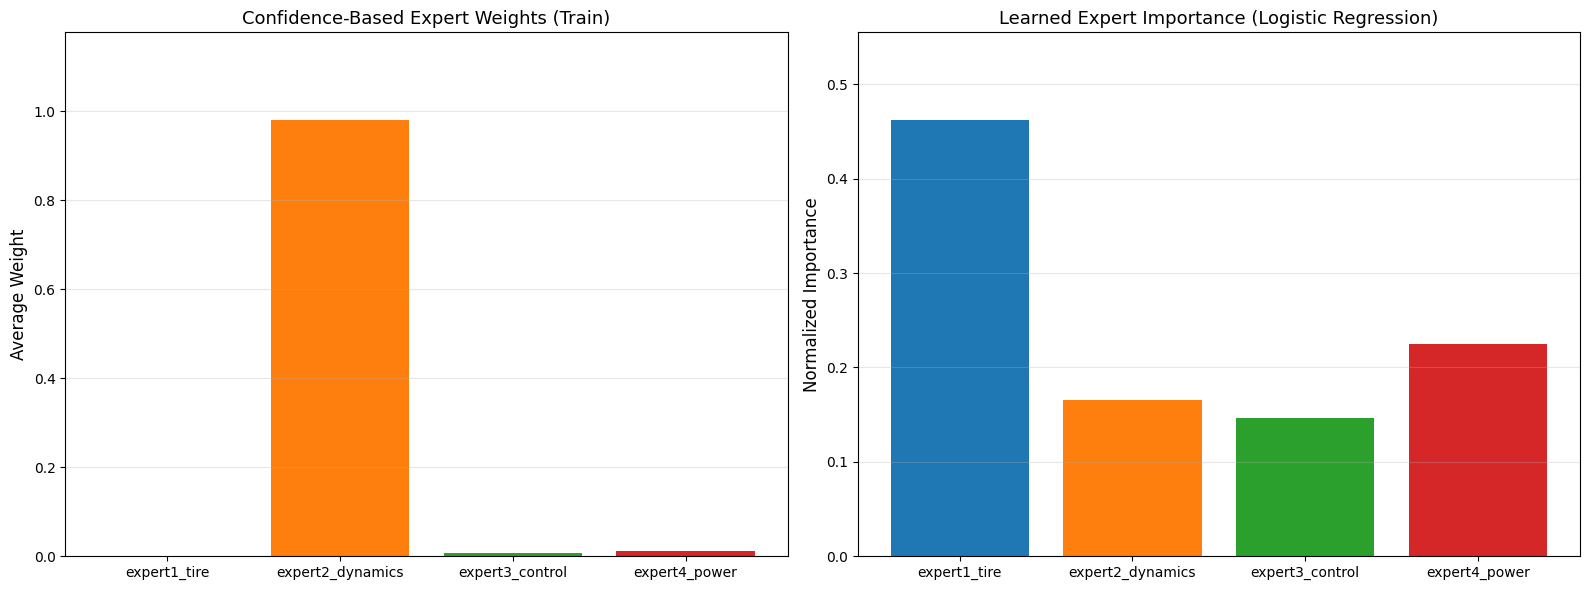

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average confidence-based weights
expert_names = list(experts.keys())
avg_weights = conf_train_weights.mean(axis=0)

axes[0].bar(expert_names, avg_weights, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_ylabel('Average Weight', fontsize=12)
axes[0].set_title('Confidence-Based Expert Weights (Train)', fontsize=13)
axes[0].set_ylim(0, max(avg_weights) * 1.2)
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Learned weights (from logistic regression coefficients)
learned_weights = np.abs(gating_model.coef_[0][:4])  # First 4 features are raw scores
learned_weights = learned_weights / learned_weights.sum()  # Normalize

axes[1].bar(expert_names, learned_weights, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_ylabel('Normalized Importance', fontsize=12)
axes[1].set_title('Learned Expert Importance (Logistic Regression)', fontsize=13)
axes[1].set_ylim(0, max(learned_weights) * 1.2)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'gating_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Final MoE Configuration

Save final MoE configuration and summary.

In [21]:
# Create MoE configuration
moe_config = {
    'experts': EXPERT_NAMES,
    'n_experts': len(EXPERT_NAMES),
    'expert_models': {name: f'gmm_{name}.pkl' for name in EXPERT_NAMES},
    'gating_model': 'gating_network.pkl',
    'thresholds': {k: float(v) for k, v in thresholds.items()},
    'gating_strategy': 'learned',  # Options: 'uniform', 'confidence', 'learned'
    'uniform_threshold': float(uniform_threshold),
    'confidence_threshold': float(conf_threshold)
}

# Save configuration
with open(MODELS_DIR / 'moe_config.json', 'w') as f:
    json.dump(moe_config, f, indent=2)

print("=" * 70)
print("MIXTURE OF EXPERTS - CONFIGURATION COMPLETE")
print("=" * 70)
print(f"\nNumber of experts: {moe_config['n_experts']}")
print(f"Gating strategy: {moe_config['gating_strategy']}")
print("\nExperts:")
for expert in moe_config['experts']:
    print(f"  - {expert}")
print(f"\nConfiguration saved to: {MODELS_DIR / 'moe_config.json'}")
print(f"Gating model saved to: {MODELS_DIR / 'gating_network.pkl'}")

MIXTURE OF EXPERTS - CONFIGURATION COMPLETE

Number of experts: 4
Gating strategy: learned

Experts:
  - expert1_tire
  - expert2_dynamics
  - expert3_control
  - expert4_power

Configuration saved to: c:\Users\victo\Desktop\Documents\Cuarto Año\Primer Cuatrimestre\F1_AC_Digital_Twin\models\anomaly-detection\moe_config.json
Gating model saved to: c:\Users\victo\Desktop\Documents\Cuarto Año\Primer Cuatrimestre\F1_AC_Digital_Twin\models\anomaly-detection\gating_network.pkl
